# Literature Material-Role Frequency

Local text-match recount over the journal-filtered corpus (`data/corpus.jsonl`). Role 1/2/3 material-frequency bars and the role-level corpus partition.

In [1]:
DROP_TITLE_ONLY = True   # v4: drop title-only papers (abstract-complete subset)

# --- v3/v4 setup: local recount over the journal-filtered corpus --------------
import re, sys, csv, json, unicodedata
from collections import Counter
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Publication style: Arial everywhere, larger fonts, crisp DPI (verbatim v2)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "mathtext.default": "regular",
    "font.size": 14,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

# repo root (robust to running from repo root or notebooks/)
REPO = next(base for base in [Path("."), Path("..")] if (base / "reports").exists())
sys.path.insert(0, str(REPO.resolve()))
from material_frequency.config import ROLES, SELECTED   # lexicon: roles -> materials (regex incl. abbreviations)

VER = "v4" if DROP_TITLE_ONLY else "v3"

def clean(s):
    """Strip Unicode control chars (Cc/Cf) — identical to the whitelist builder."""
    return "".join(c for c in s if unicodedata.category(c) not in ("Cc", "Cf")).strip()

def reconstruct_abstract(inv):
    if not inv:
        return ""
    pos = {}
    for w, ps in inv.items():
        for p in ps:
            pos[p] = w
    return " ".join(pos[i] for i in range(max(pos) + 1) if i in pos) if pos else ""

# journal whitelist + recovered Springer abstracts
whitelist = {r["journal"] for r in csv.DictReader(open(REPO / "reports" / "journals_included.csv"))}
recovered = json.loads((REPO / "data" / "recovered_abstracts.json").read_text())

# load + filter corpus; attach text = title + abstract (OpenAlex, or recovered for Springer)
papers = []
with open(REPO / "data" / "corpus.jsonl") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        d = json.loads(line)
        src = (d.get("primary_location") or {}).get("source") or {}
        if clean(src.get("display_name") or "") not in whitelist:
            continue
        abstract = reconstruct_abstract(d.get("abstract_inverted_index")) or recovered.get(d["id"], "")
        d["_abstract"] = abstract
        d["_text"] = ((d.get("title") or "") + " " + abstract).lower()
        papers.append(d)

if DROP_TITLE_ONLY:                       # v4: keep only abstract-bearing papers
    papers = [p for p in papers if p["_abstract"].strip()]
CORPUS_N = len(papers)
n_title_only = sum(1 for p in papers if not p["_abstract"].strip())

# compile per-material and per-role regex (discover.py::_lexicon_regexes pattern)
materials = []            # (role_label, key, label, selected, [compiled])
role_pats = {}            # role_index -> [compiled]
for i, (role_label, mats) in enumerate(ROLES):
    role_pats[i] = []
    for m in mats:
        pats = [re.compile(p, re.I) for p in m["regex"]]
        materials.append((role_label, m["key"], m["label"], m["selected"], pats))
        role_pats[i].extend(pats)

# per-material prevalence (overlapping: a paper may mention several materials)
rows = []
for role_label, key, label, selected, pats in materials:
    c = sum(1 for p in papers if any(rx.search(p["_text"]) for rx in pats))
    rows.append(dict(role=role_label, material=label, key=key, selected=selected,
                     abs_count=c, corpus_n=CORPUS_N,
                     prevalence_pct=round(100 * c / CORPUS_N, 3)))
df = pd.DataFrame(rows).sort_values(["role", "abs_count"], ascending=[True, False]).reset_index(drop=True)

# role-level corpus partition: precedence R1 > R2 > R3 > Other (mutually exclusive, sums to N)
def bucket_of(text):
    for i, b in [(0, "R1"), (1, "R2"), (2, "R3")]:
        if any(rx.search(text) for rx in role_pats[i]):
            return b
    return "Other"
bc = Counter(bucket_of(p["_text"]) for p in papers)
PART_FULL = {"R1": "R1 Specific Ca2+ junctions", "R2": "R2 Non-specific Ca2+ crosslink",
             "R3": "R3 -OH H-bond glue", "Other": "Other (R4 + incumbents + none)"}
pt = pd.DataFrame([dict(bucket=b, label=PART_FULL[b], abs_count=bc.get(b, 0), corpus_n=CORPUS_N,
                        share_pct=round(100 * bc.get(b, 0) / CORPUS_N, 2))
                   for b in ["R1", "R2", "R3", "Other"]])

# persist artifacts
df.to_csv(REPO / "reports" / f"material_role_frequency_{VER}.csv", index=False)
pt.to_csv(REPO / "reports" / f"role_partition_{VER}.csv", index=False)

PLOTS = REPO / "plots"; PLOTS.mkdir(exist_ok=True)
SELECTED_COLOR = "#1b7837"   # selected building block (GUM / ALG / CMC / PVA)
OTHER_COLOR    = "#bdbdbd"   # candidate considered but not selected

def cap_words(s):
    """Title-case a material name, preserving all-caps acronyms (e.g. SAP)."""
    return re.sub(r"[A-Za-z]+",
                  lambda m: m.group(0) if (m.group(0).isupper() and len(m.group(0)) > 1)
                            else m.group(0)[:1].upper() + m.group(0)[1:].lower(),
                  s)

def plot_role(role_prefix, title, all_muted=False, annotations=None, save=None):
    """Horizontal bar chart of one role's materials, counts descending (verbatim v2)."""
    sub = (df[(df["role"].str.startswith(role_prefix)) & (df["abs_count"] > 0)]
           .sort_values("abs_count", ascending=True))
    colors = [SELECTED_COLOR if (sel and not all_muted) else OTHER_COLOR
              for sel in sub["selected"]]
    fig, ax = plt.subplots(figsize=(8, 0.45 * len(sub) + 1.8))
    bars = ax.barh(sub["material"], sub["abs_count"], color=colors)
    pad = max(max(sub["abs_count"]), 1) * 0.01
    for bar, count, pct in zip(bars, sub["abs_count"], sub["prevalence_pct"]):
        ax.text(bar.get_width() + pad, bar.get_y() + bar.get_height() / 2,
                f"{int(count)}", va="center", ha="left", fontsize=12)
    disp = [cap_words(m) for m in sub["material"]]
    if annotations:
        notes = []
        for i, (label, note) in enumerate(annotations.items()):
            mark = "*" * (i + 1)
            disp = [f"{d} {mark}" if orig == label else d
                    for d, orig in zip(disp, sub["material"])]
            notes.append(f"{mark} {note}")
        fig.text(0.02, -0.02, "\n".join(notes), fontsize=12, style="italic",
                 color="#555", wrap=True)
    ax.set_yticks(range(len(disp)))
    ax.set_yticklabels(disp)
    ax.set_xlabel("Count of Papers")
    ax.set_title(title, fontsize=12, loc="left")
    ax.set_xlim(0, max(max(sub["abs_count"]), 1) * 1.30)
    ax.spines[["top", "right"]].set_visible(False)
    if not all_muted:
        ax.legend(handles=[Patch(color=SELECTED_COLOR, label="Selected Building Block"),
                           Patch(color=OTHER_COLOR, label="Candidate (Not Selected)")],
                  loc="lower right", fontsize=12, frameon=False)
    plt.tight_layout()
    if save:
        fig.savefig(save, format="svg")
    plt.show()

print(f"{VER}: CORPUS_N={CORPUS_N}  title-only-kept={n_title_only}  recovered-abstracts={len(recovered)}")


v4: CORPUS_N=464  title-only-kept=0  recovered-abstracts=74


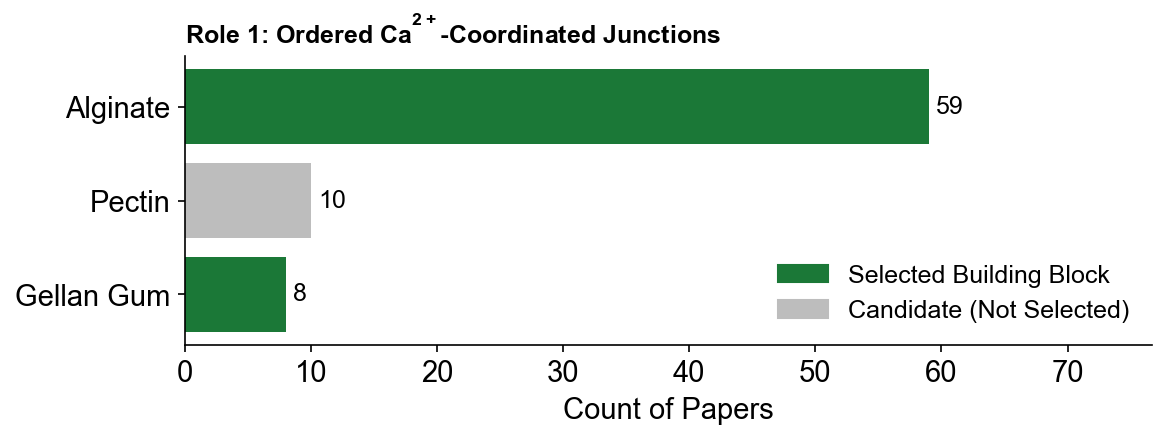

In [2]:
plot_role(
    "Role 1",
    "Role 1: Ordered Ca$^{2+}$-Coordinated Junctions",
    save=str(PLOTS / f"role1_{VER}.svg"),
)

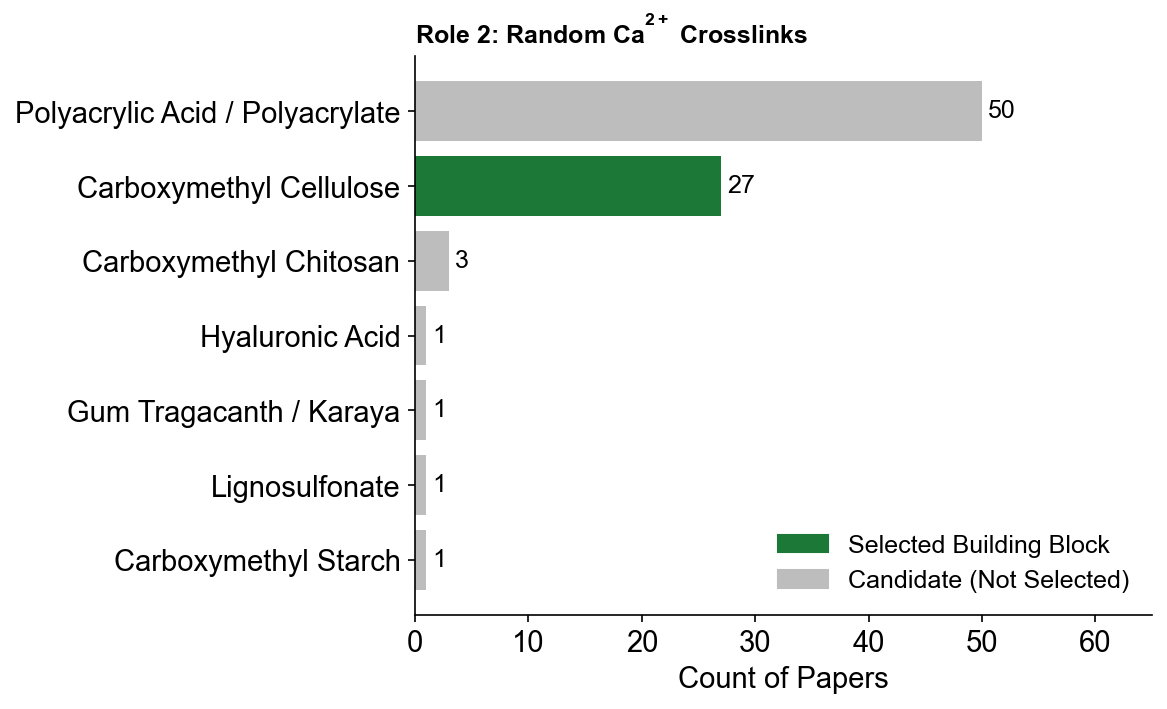

In [3]:
plot_role("Role 2", "Role 2: Random Ca$^{2+}$ Crosslinks",
          save=str(PLOTS / f"role2_{VER}.svg"))

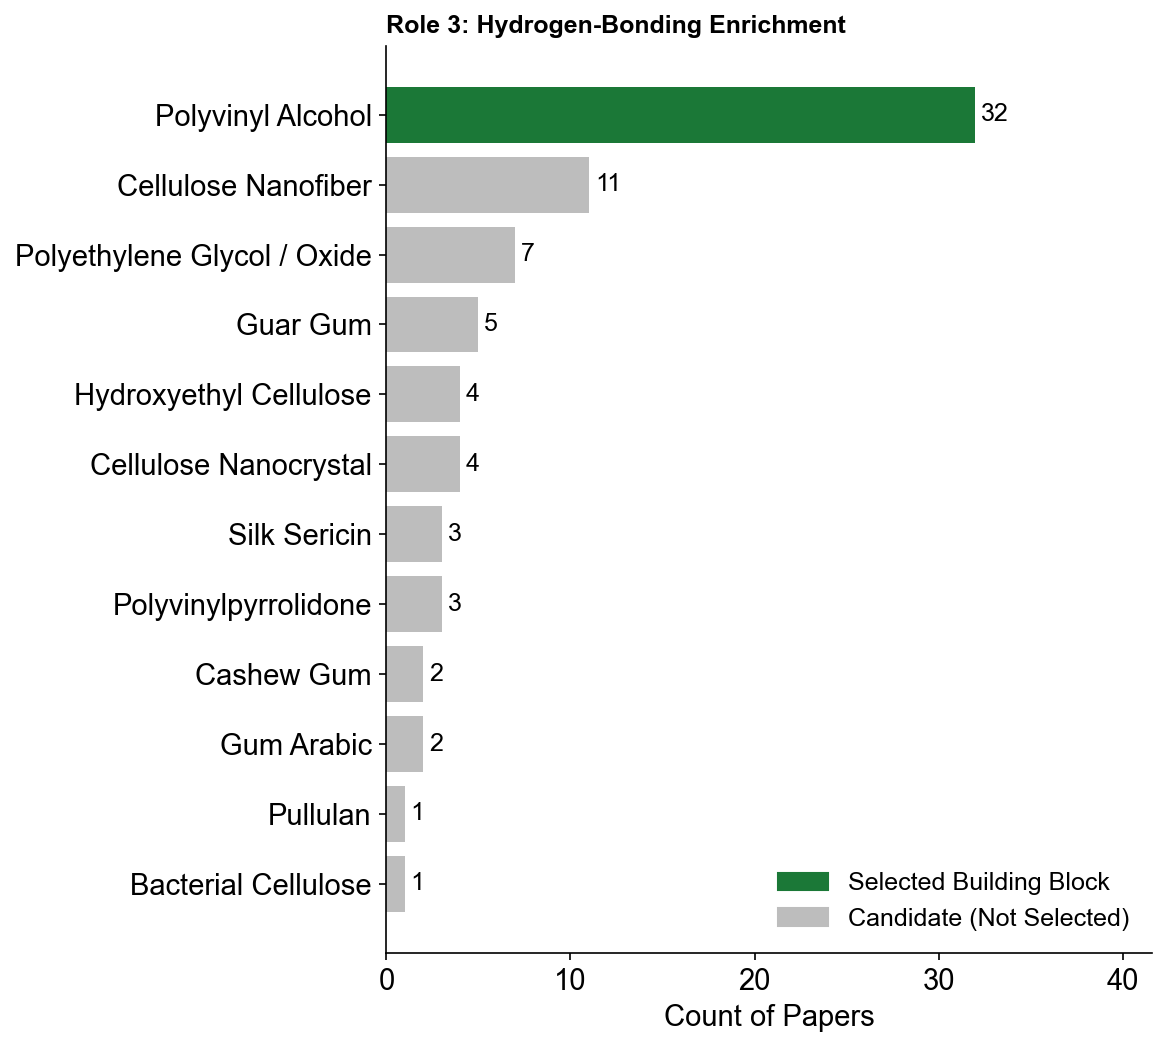

In [4]:
plot_role("Role 3", "Role 3: Hydrogen-Bonding Enrichment",
          save=str(PLOTS / f"role3_{VER}.svg"))

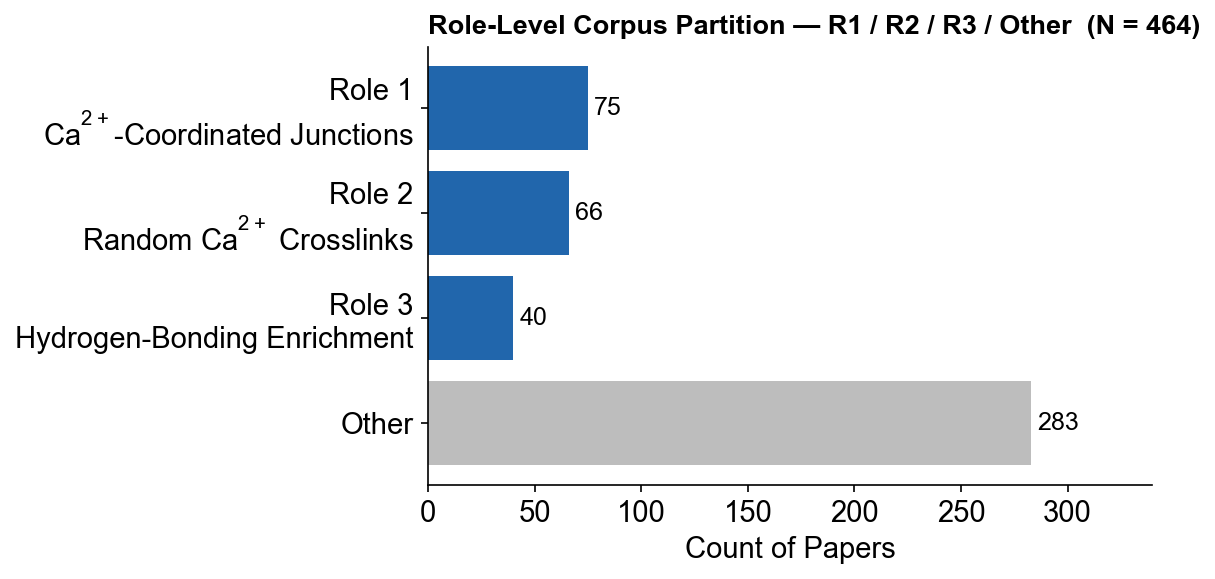

In [5]:
# --- Role-level corpus partition: R1 / R2 / R3 / Other (sums to CORPUS_N) ------
ORDER = ["Other", "R3", "R2", "R1"]            # barh draws bottom-up -> R1 on top
ptp = pt.set_index("bucket").loc[ORDER].reset_index()
PART_LABEL = {
    "R1":    "Role 1\nCa$^{2+}$-Coordinated Junctions",
    "R2":    "Role 2\nRandom Ca$^{2+}$ Crosslinks",
    "R3":    "Role 3\nHydrogen-Bonding Enrichment",
    "Other": "Other",
}
ylabels = [PART_LABEL[b] for b in ptp["bucket"]]
colors = [OTHER_COLOR if b == "Other" else "#2166ac" for b in ptp["bucket"]]
fig, ax = plt.subplots(figsize=(8, 0.62 * len(ptp) + 1.6))
bars = ax.barh(range(len(ptp)), ptp["abs_count"], color=colors)
ax.set_yticks(range(len(ptp)))
ax.set_yticklabels(ylabels)
for bar, c, pct in zip(bars, ptp["abs_count"], ptp["share_pct"]):
    ax.text(bar.get_width() + max(ptp["abs_count"]) * 0.01,
            bar.get_y() + bar.get_height() / 2, f"{int(c)}",
            va="center", ha="left", fontsize=12)
ax.set_xlabel("Count of Papers")
ax.set_title(f"Role-Level Corpus Partition — R1 / R2 / R3 / Other  (N = {CORPUS_N:,})",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlim(0, max(ptp["abs_count"]) * 1.20)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(PLOTS / f"role_level_corpus_partition_{VER}.svg", format="svg")
plt.show()